# AgroScan — Jalon 5 : Multi-têtes + Segmentation

> **Par rapport au précédent**, ce notebook corrige le **fort surapprentissage observé en Phase 3**
> (l'accuracy d'entraînement montait pendant que la validation PlantDoc stagnait ~0.46). Leviers :
> backbone **moins dégelé** en Phase 3 (25 % au lieu de 40 %), **dropout 0.40**, **L2** sur les têtes,
> **AdamW (weight decay)**, **label smoothing 0.10**, et **early stopping** plus serré (moins d'époques).

Ce notebook **combine les deux meilleures approches** obtenues jusqu'ici :

1. **Modèle multi-têtes** (`jalon4_two_head.ipynb`) — un backbone MobileNetV3Small partagé
   et deux têtes (espèce + maladie). C'est l'approche qui **préserve le mieux PlantVillage**
   (top-1 ≈ 82.9 %) tout en donnant le meilleur score *direct* sur PlantDoc (top-1 ≈ 49–51 %).
2. **Segmentation rembg** (`jalon4_segmentation_experiment.ipynb`) — neutralisation du fond
   (rembg + masque vert de secours + crop). Le fine-tuning *mixte original + segmenté* est le
   levier qui poussait PlantDoc original à ≈ 51.7 % (mais au prix d'un oubli fort de PlantVillage
   quand on l'appliquait seul sur l'espace 38 classes).

**Idée de la fusion :** garder l'ossature multi-têtes en 3 phases (qui retient PlantVillage),
et injecter en **Phase 3** une **troisième vue** des données terrain : PlantDoc segmenté, en plus
de PlantDoc original et du replay PlantVillage. On obtient ainsi le boost terrain de la
segmentation **sans** sacrifier la rétention studio.

```
                MobileNetV3Small (backbone partagé)
                              │
                    GlobalAveragePooling2D
                              │
                        Dropout(0.25)
                         ↙          ↘
                  Tête espèce      Tête maladie
                  Dense(13)         Dense(27)
                  softmax           softmax  (sortie principale)
```

**Stratégie d'entraînement :**
- Phase 1 : PlantVillage (backbone gelé)
- Phase 2 : PlantWild (25 % dégelé) — pont terrain
- Phase 3 : mixte **PlantDoc original (40 %) + PlantDoc segmenté (30 %) + replay PV (30 %)** (40 % dégelé)

**Objectifs :** améliorer PlantDoc **et** garder de bons résultats sur PlantVillage.
On rapporte systématiquement **Top-1, Top-3, macro F1** et une **analyse d'erreurs** détaillée.


## 1. Lancement

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

Si `rembg` n'est pas installé : `pip install -r requirements.txt` (au premier appel, rembg
télécharge son modèle de segmentation).


In [1]:
# %pip install -r ../requirements.txt kagglehub rembg opencv-python

In [2]:
%pip install rembg[cpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 88.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 97.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 95.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numb

In [3]:
import shutil
import subprocess
import os
import time
from pathlib import Path
from difflib import SequenceMatcher
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps

import cv2
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

try:
    from rembg import remove, new_session
except ImportError as exc:
    raise ImportError(
        "La dependance rembg est manquante. Installer avec `pip install -r requirements.txt`, "
        "puis redemarrer le kernel."
    ) from exc

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-06-06 21:12:34.318964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780780354.693369      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780780354.815872      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780780355.819824      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780780355.819860      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780780355.819863      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

On réunit ici les hyperparamètres du modèle multi-têtes **et** les paramètres de segmentation.


In [ ]:
# Detection robuste de la racine projet
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
IS_COLAB  = Path('/content').exists() and Path('/opt/google').exists()
_colab_root = Path('/content') if IS_COLAB else None
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents
])))
ROOT = next(
    (p for p in _candidates if (p / 'requirements.txt').exists()),
    _env_root or _colab_root or _cwd,
)

DATA_DIR   = ROOT / 'data'
# MODEL_DIR  = ROOT / 'models'
MODEL_DIR = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = ROOT / 'reports'

SEGMENTED_DIR          = DATA_DIR / 'segmented'
SEGMENTED_PLANTDOC_DIR = SEGMENTED_DIR / 'plantdoc_rembg_crop_gray'
COMBINED_REPORT_DIR    = REPORT_DIR / 'two_head_seg'

if IS_COLAB:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount('/content/drive', force_remount=False)
        _drive_root = Path('/content/drive/MyDrive/agroscan')
        MODEL_DIR   = _drive_root / 'models'
        REPORT_DIR  = _drive_root / 'reports'
        COMBINED_REPORT_DIR = REPORT_DIR / 'two_head_seg'
        print('Google Drive monte -> artefacts dans :', _drive_root)
    except Exception as _e:
        print(f'Drive non disponible ({_e}) - sauvegarde locale /content uniquement.')

for d in [MODEL_DIR, REPORT_DIR, COMBINED_REPORT_DIR, SEGMENTED_PLANTDOC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

MH_EPOCHS_P1, MH_LR_P1, MH_PAT_P1 = 15, 1e-3, 3
MH_EPOCHS_P2, MH_LR_P2, MH_PAT_P2, MH_UNFREEZE_P2 = 20, 1e-4, 4, 0.75
MH_EPOCHS_P3, MH_LR_P3, MH_PAT_P3, MH_UNFREEZE_P3 = 30, 2e-5, 6, 0.75

MIX_RATIO_PD_ORIG = 0.40
MIX_RATIO_PD_SEG  = 0.30
MIX_RATIO_PV      = 0.30
LABEL_SMOOTHING   = 0.05
LABEL_SMOOTHING_P3 = 0.10   

DROPOUT_RATE    = 0.40   
HEAD_L2         = 1e-4   # penalite L2 sur les tetes Dense
WEIGHT_DECAY_P3 = 1e-4   

LOSS_WEIGHT_SPECIES = 0.3
LOSS_WEIGHT_DISEASE = 0.7

SEG_MODEL = 'isnet-general-use'
KEEP_COMPONENTS = 3
SEGMENTATION_MASK_MODE = 'rembg_green_fallback' 
MASK_MIN_AREA_RATIO = 0.05
MASK_DILATE_ITER = 1
GREEN_MASK_MIN_SATURATION = 28
GREEN_MASK_EXCESS_THRESHOLD = 22
GREEN_MASK_DOMINANCE = 1.05
GREEN_FALLBACK_REMBG_MAX_AREA_RATIO = 0.15
GREEN_FALLBACK_MAX_AREA_RATIO = 0.30
GREEN_FALLBACK_TAKE_GREEN_MIN_AREA_RATIO = 0.35
GREEN_FALLBACK_TAKE_GREEN_MAX_AREA_RATIO = 0.90
BACKGROUND_COLOR = (235, 235, 235)
CROP_TO_MASK = True
CROP_PADDING_RATIO = 0.12
FORCE_RESEGMENT = False 

tf.keras.utils.set_random_seed(SEED)
print('Racine projet :', ROOT)
print('Models        :', MODEL_DIR)
print('Cache seg.    :', SEGMENTED_PLANTDOC_DIR)

Racine projet : /
Models        : /kaggle/working/models
Cache seg.    : /data/segmented/plantdoc_rembg_crop_gray


## 3. Chargement de PlantVillage

In [ ]:
import re

PV_KAGGLE_SLUG = 'mohitsingh1804/plantvillage'
PV_LABELS = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew',
    'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy',
    'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)',
    'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
    'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy',
    'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
]

_PV_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
_PV_SKIP_PARTS = {'grayscale', 'segmented'}


def _pv_simplify(name):
    s = name.lower().replace('(maize)', '').replace('(including_sour)', '')
    return re.sub(r'[^a-z]', '', s)


_PV_CANON = {_pv_simplify(l): l for l in PV_LABELS}
_PV_LABEL_TO_IDX = {l: i for i, l in enumerate(PV_LABELS)}


def _pv_collect(root):
    found = {}
    for dirpath, dirnames, _ in os.walk(root):
        parts = {p.lower() for p in Path(dirpath).parts}
        if parts & _PV_SKIP_PARTS:
            dirnames[:] = []
            continue
        for dn in list(dirnames):
            canon = _PV_CANON.get(_pv_simplify(dn))
            if canon is not None:
                found.setdefault(canon, []).append(Path(dirpath) / dn)
    return found


def _pv_root():
    candidates = []
    if 'PLANTVILLAGE_DIR' in os.environ:
        candidates.append(Path(os.environ['PLANTVILLAGE_DIR']))
    candidates += [DATA_DIR / 'plantvillage', Path('/kaggle/input/plantvillage')]
    kin = Path('/kaggle/input')
    if kin.exists():
        candidates += [p for p in kin.iterdir() if p.is_dir()]
    for c in candidates:
        if c and Path(c).exists():
            found = _pv_collect(c)
            if len(found) >= 20:
                return Path(c), found
    import kagglehub
    p = Path(kagglehub.dataset_download(PV_KAGGLE_SLUG))
    return p, _pv_collect(p)


def load_plant_village(seed=SEED):
    root, found = _pv_root()
    if len(found) < 20:
        raise FileNotFoundError(
            f'PlantVillage introuvable ({len(found)} classes). Ajoute le dataset Kaggle '
            f'"{PV_KAGGLE_SLUG}" en input, ou definis os.environ["PLANTVILLAGE_DIR"].')
    print(f'PlantVillage : {len(found)}/{len(PV_LABELS)} classes trouvees dans {root}')

    paths, labels = [], []
    for canon, dirs in found.items():
        idx = _PV_LABEL_TO_IDX[canon]
        for cls_path in dirs:
            for p in cls_path.iterdir():
                if p.is_file() and p.suffix.lower() in _PV_IMG_EXTS:
                    paths.append(str(p))
                    labels.append(idx)
    paths = np.array(paths)
    labels = np.array(labels, dtype=np.int64)

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(paths))
    paths, labels = paths[perm], labels[perm]
    n = len(paths)
    i70, i85 = int(0.70 * n), int(0.85 * n)
    bounds = {'train': (0, i70), 'val': (i70, i85), 'test': (i85, n)}
    print(f'  {n} images -> train {i70} | val {i85 - i70} | test {n - i85}')

    def _decode(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        return img, label

    def _make(name):
        a, b = bounds[name]
        return (tf.data.Dataset.from_tensor_slices((paths[a:b], labels[a:b]))
                .map(_decode, num_parallel_calls=AUTOTUNE))

    return (_make('train'), _make('val'), _make('test')), PV_LABELS


(pv_train_raw, pv_val_raw, pv_test_raw), class_names = load_plant_village()
num_classes_pv  = len(class_names)
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes_pv} classes')
print(f'Ex. : {class_names[:5]}')

PlantVillage : 38/38 classes trouvees dans /kaggle/input/datasets
  56969 images -> train 39878 | val 8545 | test 8546


I0000 00:00:1780780597.521080      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780780597.527338      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


PlantVillage : 38 classes
Ex. : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 4. Configuration PlantDoc + mapping

In [6]:
PLANTDOC_DIR       = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':              'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('Telechargement de PlantDoc...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp = DATA_DIR / '_pd_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git', str(tmp)],
        check=True,
    )
    for split in ('train', 'test'):
        src, dst = tmp / split, PLANTDOC_DIR / split
        if src.exists() and not dst.exists():
            shutil.copytree(src, dst)
    shutil.rmtree(tmp)
    print('PlantDoc telecharge.')

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
print(f'PlantDoc test : {len(plantdoc_classes)} classes | {len(valid_pd_mapping)} evaluables')

Telechargement de PlantDoc...


Cloning into '/data/_pd_clone'...
Updating files: 100% (2581/2581), done.


PlantDoc telecharge.
PlantDoc test : 27 classes | 27 evaluables


## 5. Univers restreint aux 27 classes PlantDoc

In [7]:
allowed_pv_names = sorted(set(valid_pd_mapping.values()))
allowed_pv_idx   = [pv_label_to_idx[n] for n in allowed_pv_names]
allowed_set      = set(allowed_pv_idx)
n_allowed        = len(allowed_pv_idx)

global_to_pos = {g: pos for pos, g in enumerate(allowed_pv_idx)}
pos_to_name   = {pos: class_names[g] for g, pos in global_to_pos.items()}

allowed_idx_tensor = tf.constant(allowed_pv_idx, dtype=tf.int64)

print(f'Univers restreint : {n_allowed} classes PlantDoc')
for pos in range(n_allowed):
    print(f'  [{pos:2d}] {pos_to_name[pos]}')

Univers restreint : 27 classes PlantDoc
  [ 0] Apple___Apple_scab
  [ 1] Apple___Cedar_apple_rust
  [ 2] Apple___healthy
  [ 3] Blueberry___healthy
  [ 4] Cherry___healthy
  [ 5] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [ 6] Corn___Common_rust
  [ 7] Corn___Northern_Leaf_Blight
  [ 8] Grape___Black_rot
  [ 9] Grape___healthy
  [10] Peach___healthy
  [11] Pepper,_bell___Bacterial_spot
  [12] Pepper,_bell___healthy
  [13] Potato___Early_blight
  [14] Potato___Late_blight
  [15] Raspberry___healthy
  [16] Soybean___healthy
  [17] Squash___Powdery_mildew
  [18] Strawberry___healthy
  [19] Tomato___Bacterial_spot
  [20] Tomato___Early_blight
  [21] Tomato___Late_blight
  [22] Tomato___Leaf_Mold
  [23] Tomato___Septoria_leaf_spot
  [24] Tomato___Tomato_Yellow_Leaf_Curl_Virus
  [25] Tomato___Tomato_mosaic_virus
  [26] Tomato___healthy


## 6. Taxonomie espèce / maladie

In [8]:
def species_of(pv_name):
    return pv_name.split('___')[0]

species_names  = sorted(set(species_of(n) for n in allowed_pv_names))
species_to_idx = {s: i for i, s in enumerate(species_names)}
n_species      = len(species_names)

def clean_name(s):
    out = s
    for ch in (',', ' ', '(', ')', '/', '\\'):
        out = out.replace(ch, '_')
    while '__' in out:
        out = out.replace('__', '_')
    return out.strip('_')

species_display = [clean_name(s) for s in species_names]

# Lookup : pv_global_idx -> species_idx
pv_to_species_arr = np.full(num_classes_pv, -1, dtype=np.int64)
for g in allowed_pv_idx:
    pv_to_species_arr[g] = species_to_idx[species_of(class_names[g])]
pv_to_species_tensor = tf.constant(pv_to_species_arr, dtype=tf.int64)

# Lookup : pv_global_idx -> position dans l'univers
pv_to_pos_arr = np.full(num_classes_pv, -1, dtype=np.int64)
for g, pos in global_to_pos.items():
    pv_to_pos_arr[g] = pos
pv_to_pos_tensor = tf.constant(pv_to_pos_arr, dtype=tf.int64)

species_disease_global = {s: [] for s in range(n_species)}
for g in allowed_pv_idx:
    species_disease_global[species_to_idx[species_of(class_names[g])]].append(g)
for s in species_disease_global:
    species_disease_global[s] = sorted(species_disease_global[s])

multi_species = [s for s in range(n_species) if len(species_disease_global[s]) > 1]
mono_species  = [s for s in range(n_species) if len(species_disease_global[s]) == 1]

print(f'{n_species} especes, {n_allowed} classes maladie (univers PlantDoc)')
print(f'{len(multi_species)} especes multi-maladies, {len(mono_species)} mono-classe')

13 especes, 27 classes maladie (univers PlantDoc)
6 especes multi-maladies, 7 mono-classe


## 7. Chargement et mapping de PlantWild

In [9]:
PLANTWILD_DIR = DATA_DIR / 'plantwild'

if not PLANTWILD_DIR.exists():
    print('PlantWild non trouve. Tentative de telechargement via kagglehub...')
    try:
        import kagglehub
        path = kagglehub.dataset_download('thuanai1/plantwild')
        PLANTWILD_DIR = Path(path)
        print('Telecharge dans :', PLANTWILD_DIR)
    except Exception as e:
        raise FileNotFoundError(
            f'PlantWild non trouve ({e}).\n'
            'Telecharger sur https://www.kaggle.com/datasets/thuanai1/plantwild\n'
            'et extraire dans data/plantwild/ (train/ val/)'
        ) from e

for candidate in [PLANTWILD_DIR, PLANTWILD_DIR / 'plantwild', *list(PLANTWILD_DIR.iterdir())]:
    if (candidate / 'train').exists():
        PLANTWILD_TRAIN_DIR = candidate / 'train'
        PLANTWILD_VAL_DIR   = candidate / 'val'
        break
else:
    raise FileNotFoundError(f'Structure train/ introuvable dans {PLANTWILD_DIR}')

print('PlantWild train :', PLANTWILD_TRAIN_DIR)

PlantWild non trouve. Tentative de telechargement via kagglehub...
Telecharge dans : /kaggle/input/datasets/thuanai1/plantwild
PlantWild train : /kaggle/input/datasets/thuanai1/plantwild/train


In [10]:
plantwild_to_plantvillage = {
    'apple scab':                    'Apple___Apple_scab',
    'apple black rot':               'Apple___Black_rot',
    'apple rust':                    'Apple___Cedar_apple_rust',
    'apple leaf':                    'Apple___healthy',
    'blueberry leaf':                'Blueberry___healthy',
    'cherry leaf':                   'Cherry___healthy',
    'cherry powdery mildew':         'Cherry___Powdery_mildew',
    'corn gray leaf spot':           'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight':              'Corn___Northern_Leaf_Blight',
    'corn rust':                     'Corn___Common_rust',
    'corn leaf':                     'Corn___healthy',
    'grape black rot':               'Grape___Black_rot',
    'grape esca':                    'Grape___Esca_(Black_Measles)',
    'grape leaf blight':             'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf':                    'Grape___healthy',
    'orange citrus greening':        'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing':          'Orange___Haunglongbing_(Citrus_greening)',
    'peach bacterial spot':          'Peach___Bacterial_spot',
    'peach leaf':                    'Peach___healthy',
    'bell pepper leaf spot':         'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf':              'Pepper,_bell___healthy',
    'potato early blight':           'Potato___Early_blight',
    'potato late blight':            'Potato___Late_blight',
    'potato leaf':                   'Potato___healthy',
    'raspberry leaf':                'Raspberry___healthy',
    'soybean leaf':                  'Soybean___healthy',
    'squash powdery mildew':         'Squash___Powdery_mildew',
    'strawberry leaf scorch':        'Strawberry___Leaf_scorch',
    'strawberry leaf':               'Strawberry___healthy',
    'tomato bacterial spot':         'Tomato___Bacterial_spot',
    'tomato early blight':           'Tomato___Early_blight',
    'tomato late blight':            'Tomato___Late_blight',
    'tomato leaf mold':              'Tomato___Leaf_Mold',
    'tomato septoria leaf spot':     'Tomato___Septoria_leaf_spot',
    'tomato spider mites':           'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot':            'Tomato___Target_Spot',
    'tomato yellow leaf curl virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus':           'Tomato___Tomato_mosaic_virus',
    'tomato leaf':                   'Tomato___healthy',
}
print(f'Mapping PlantWild -> PV : {len(plantwild_to_plantvillage)} entrees')

Mapping PlantWild -> PV : 39 entrees


In [11]:
def fuzzy_match(query, candidates, threshold=0.7):
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best, best_score = c, score
    return best if best_score >= threshold else None


def load_plantwild_split(split_dir):
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths, labels = [], []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name.lower()
        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            match = fuzzy_match(cls_name, list(plantwild_to_plantvillage.keys()))
            if match:
                pv_cls = plantwild_to_plantvillage[match]
        if pv_cls is None or pv_cls not in pv_label_to_idx:
            continue
        pv_idx = pv_label_to_idx[pv_cls]
        if pv_idx not in allowed_set:
            continue
        for p in cls_dir.iterdir():
            if p.is_file() and p.suffix.lower() in image_exts:
                paths.append(str(p))
                labels.append(pv_idx)
    return paths, labels


pw_train_paths, pw_train_labels = load_plantwild_split(PLANTWILD_TRAIN_DIR)
if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels = load_plantwild_split(PLANTWILD_VAL_DIR)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths  = [pw_train_paths[i]  for i in perm]
    pw_train_labels = [pw_train_labels[i] for i in perm]
    n_val = int(0.2 * len(pw_train_paths))
    pw_val_paths,   pw_val_labels   = pw_train_paths[:n_val],  pw_train_labels[:n_val]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val:],  pw_train_labels[n_val:]

print(f'PlantWild (univers 27) train : {len(pw_train_paths):,} | val : {len(pw_val_labels):,}')
print(f'Classes couvertes : {len(set(pw_train_labels))} / {n_allowed}')

PlantWild (univers 27) train : 7,074 | val : 994
Classes couvertes : 27 / 27


## 8. Collecte des images PlantDoc train (univers 27)

In [12]:
pd_train_paths, pd_train_glob = [], []
for pd_cls, pv_cls in valid_pd_mapping.items():
    cls_dir = PLANTDOC_TRAIN_DIR / pd_cls
    g = pv_label_to_idx.get(pv_cls)
    if g is None or g not in allowed_set or not cls_dir.exists():
        continue
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            pd_train_paths.append(str(p))
            pd_train_glob.append(g)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(pd_train_paths))
pd_train_paths = [pd_train_paths[i] for i in perm]
pd_train_glob  = [pd_train_glob[i]  for i in perm]

n_val_pd = int(0.2 * len(pd_train_paths))
pd_val_paths,   pd_val_glob   = pd_train_paths[:n_val_pd], pd_train_glob[:n_val_pd]
pd_train_paths, pd_train_glob = pd_train_paths[n_val_pd:], pd_train_glob[n_val_pd:]

print(f'PlantDoc train : {len(pd_train_paths):,} | val : {len(pd_val_paths):,}')
print(f'Classes couvertes : {len(set(pd_train_glob))} / {n_allowed}')

PlantDoc train : 1,872 | val : 468
Classes couvertes : 27 / 27


## 9. Segmentation rembg de PlantDoc

`rembg` retourne un masque de premier plan, complété par un masque vert de secours (feuilles
ratées par rembg), nettoyé par morphologie OpenCV puis recadré. Sortie = **crop + fond gris clair**.


In [13]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
seg_session = new_session(SEG_MODEL)


def list_images(root):
    return sorted(p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


def make_green_leaf_mask(image_rgb):
    # Masque couleur permissif : filet de securite quand rembg garde seulement
    # les fruits, tiges ou lesions tres contrastees.
    img = np.asarray(image_rgb).astype(np.float32)
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    excess_green = 2 * g - r - b
    green_dominant = (g > r * GREEN_MASK_DOMINANCE) & (g > b * GREEN_MASK_DOMINANCE)
    saturated = (img.max(axis=-1) - img.min(axis=-1)) > GREEN_MASK_MIN_SATURATION
    mask = ((excess_green > GREEN_MASK_EXCESS_THRESHOLD) | green_dominant) & saturated
    return mask.astype(np.uint8) * 255


def build_leaf_mask(image_rgb, rembg_mask_uint8):
    rembg_mask = (rembg_mask_uint8 > 20).astype(np.uint8) * 255
    rembg_area = float((rembg_mask > 0).mean())

    if SEGMENTATION_MASK_MODE == 'rembg':
        return rembg_mask

    green_mask = make_green_leaf_mask(image_rgb)
    green_area = float((green_mask > 0).mean())
    hybrid_mask = np.maximum(rembg_mask, green_mask)
    hybrid_area = float((hybrid_mask > 0).mean())

    if SEGMENTATION_MASK_MODE == 'rembg_green_union':
        return hybrid_mask

    if SEGMENTATION_MASK_MODE == 'rembg_green_fallback':
        if rembg_area <= GREEN_FALLBACK_REMBG_MAX_AREA_RATIO:
            if hybrid_area <= GREEN_FALLBACK_MAX_AREA_RATIO:
                return hybrid_mask
            if GREEN_FALLBACK_TAKE_GREEN_MIN_AREA_RATIO <= green_area <= GREEN_FALLBACK_TAKE_GREEN_MAX_AREA_RATIO:
                return green_mask
        return rembg_mask

    raise ValueError(f'Mode de masque inconnu : {SEGMENTATION_MASK_MODE}')


def clean_mask(mask_uint8, keep_components=3):
    mask = (mask_uint8 > 20).astype(np.uint8) * 255
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    if n_labels <= 1:
        return mask

    component_ids = list(range(1, n_labels))
    component_ids.sort(key=lambda i: stats[i, cv2.CC_STAT_AREA], reverse=True)
    selected = component_ids[:keep_components]
    cleaned = np.isin(labels, selected).astype(np.uint8) * 255

    if MASK_DILATE_ITER > 0:
        cleaned = cv2.dilate(cleaned, kernel, iterations=MASK_DILATE_ITER)
    return cleaned


def crop_box_from_mask(mask_uint8, padding_ratio=0.08):
    ys, xs = np.where(mask_uint8 > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    h, w = mask_uint8.shape
    pad = int(max(x2 - x1 + 1, y2 - y1 + 1) * padding_ratio)
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(w - 1, x2 + pad)
    y2 = min(h - 1, y2 + pad)
    return (x1, y1, x2 + 1, y2 + 1)


def segment_image(src_path, dst_path):
    image = ImageOps.exif_transpose(Image.open(src_path)).convert('RGB')
    mask_pil = remove(image, session=seg_session, only_mask=True, post_process_mask=True)
    mask = np.array(mask_pil.convert('L'))
    mask = build_leaf_mask(image, mask)
    mask = clean_mask(mask, keep_components=KEEP_COMPONENTS)

    area_ratio = float((mask > 0).mean())
    status = 'ok'
    if area_ratio < MASK_MIN_AREA_RATIO:
        status = 'mask_too_small_original_kept'
        out = image.copy()
        box = None
    else:
        bg = Image.new('RGB', image.size, BACKGROUND_COLOR)
        out = Image.composite(image, bg, Image.fromarray(mask))
        box = crop_box_from_mask(mask, CROP_PADDING_RATIO) if CROP_TO_MASK else None
        if box is not None:
            out = out.crop(box)

    out = out.resize(IMG_SIZE, Image.Resampling.BILINEAR)
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    out.save(dst_path, quality=95)
    return {'src': str(src_path), 'dst': str(dst_path),
            'mask_area_ratio': area_ratio, 'status': status, 'crop_box': box}


def segment_split(src_root, dst_root, force=False):
    rows = []
    images = list_images(src_root)
    print(f'{src_root.name}: {len(images)} images a traiter')
    t0 = time.time()
    for i, src in enumerate(images, start=1):
        rel = src.relative_to(src_root)
        dst = dst_root / rel.with_suffix('.jpg')
        if dst.exists() and not force:
            rows.append({'src': str(src), 'dst': str(dst), 'mask_area_ratio': np.nan,
                         'status': 'cached', 'crop_box': None})
            continue
        try:
            rows.append(segment_image(src, dst))
        except Exception as exc:
            rows.append({'src': str(src), 'dst': str(dst), 'mask_area_ratio': np.nan,
                         'status': f'error: {exc}', 'crop_box': None})
        if i % 100 == 0 or i == len(images):
            print(f'  {i:>5}/{len(images)} images - {time.time() - t0:.0f}s')
    return pd.DataFrame(rows)

print('Fonctions de segmentation pretes.')

  0%|                                               | 0.00/179M [00:00<?, ?B/s]

Fonctions de segmentation pretes.


## 10. Génération du cache PlantDoc segmenté

Peut prendre plusieurs minutes au premier passage. Relançable : les images déjà segmentées
sont réutilisées sauf si `FORCE_RESEGMENT=True`.


In [14]:
seg_train_dir = SEGMENTED_PLANTDOC_DIR / 'train'
seg_test_dir  = SEGMENTED_PLANTDOC_DIR / 'test'

train_seg_report = segment_split(PLANTDOC_TRAIN_DIR, seg_train_dir, force=FORCE_RESEGMENT)
test_seg_report  = segment_split(PLANTDOC_TEST_DIR,  seg_test_dir,  force=FORCE_RESEGMENT)

seg_report = pd.concat([
    train_seg_report.assign(split='train'),
    test_seg_report.assign(split='test'),
], ignore_index=True)
seg_report.to_csv(COMBINED_REPORT_DIR / 'plantdoc_segmentation_report.csv', index=False)

display(seg_report.groupby(['split', 'status']).size().reset_index(name='n'))

train: 2342 images a traiter
    100/2342 images - 205s
    200/2342 images - 390s
    300/2342 images - 587s
    400/2342 images - 785s
    500/2342 images - 990s
    600/2342 images - 1173s
    700/2342 images - 1384s
    800/2342 images - 1572s
    900/2342 images - 1787s
   1000/2342 images - 1969s
   1100/2342 images - 2159s
   1200/2342 images - 2349s
   1300/2342 images - 2576s
   1400/2342 images - 2787s
   1500/2342 images - 2994s
   1600/2342 images - 3189s
   1700/2342 images - 3363s
   1800/2342 images - 3553s
   1900/2342 images - 3747s
   2000/2342 images - 3943s
   2100/2342 images - 4121s
   2200/2342 images - 4321s
   2300/2342 images - 4534s
   2342/2342 images - 4617s
test: 236 images a traiter
    100/236 images - 205s
    200/236 images - 400s
    236/236 images - 473s


,split,status,n
0,test,mask_too_small_original_kept,15
1,test,ok,221
2,train,mask_too_small_original_kept,176
3,train,ok,2166


## 11. Inspection visuelle avant / après

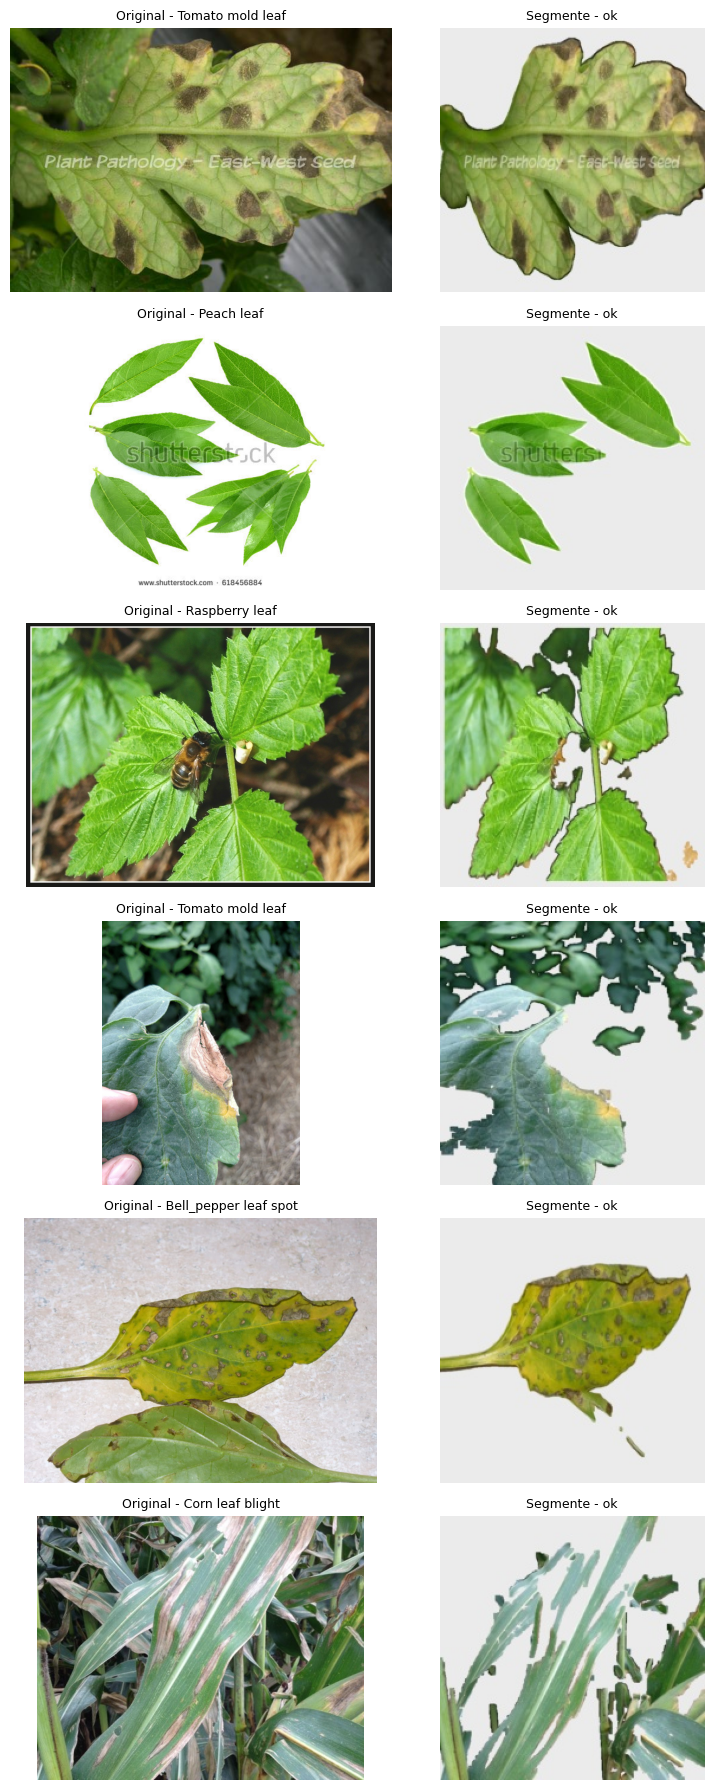

In [15]:
sample_rows = seg_report[seg_report['status'].isin(['ok', 'cached'])].sample(
    n=min(6, len(seg_report)), random_state=SEED
)

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, 3 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    axes[row_idx, 0].imshow(Image.open(row['src']).convert('RGB'))
    axes[row_idx, 0].set_title(f"Original - {Path(row['src']).parent.name}", fontsize=9)
    axes[row_idx, 0].axis('off')
    axes[row_idx, 1].imshow(Image.open(row['dst']).convert('RGB'))
    axes[row_idx, 1].set_title(f"Segmente - {row['status']}", fontsize=9)
    axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.savefig(COMBINED_REPORT_DIR / 'segmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Collecte des chemins PlantDoc segmentés (alignés sur le split original)

On fait correspondre chaque image PlantDoc train/val à sa version segmentée, pour garder
**exactement le même découpage** train/val que l'original (pas de fuite).


In [16]:
def orig_to_seg(orig_path, orig_root, seg_root):
    p = Path(orig_path)
    rel = p.relative_to(orig_root)
    return seg_root / rel.with_suffix('.jpg')


def map_to_segmented(paths, globs, orig_root, seg_root):
    seg_paths, seg_globs = [], []
    for pth, g in zip(paths, globs):
        sp = orig_to_seg(pth, orig_root, seg_root)
        if sp.exists():
            seg_paths.append(str(sp))
            seg_globs.append(g)
    return seg_paths, seg_globs


pd_seg_train_paths, pd_seg_train_glob = map_to_segmented(
    pd_train_paths, pd_train_glob, PLANTDOC_TRAIN_DIR, seg_train_dir)
pd_seg_val_paths, pd_seg_val_glob = map_to_segmented(
    pd_val_paths, pd_val_glob, PLANTDOC_TRAIN_DIR, seg_train_dir)

print(f'PlantDoc segmente train : {len(pd_seg_train_paths):,} (sur {len(pd_train_paths):,} originaux)')
print(f'PlantDoc segmente val   : {len(pd_seg_val_paths):,} (sur {len(pd_val_paths):,} originaux)')

PlantDoc segmente train : 1,872 (sur 1,872 originaux)
PlantDoc segmente val   : 468 (sur 468 originaux)


## 13. Augmentation et fonctions de chargement (double label)

Toutes les fonctions retournent `(image, {'species': y_sp, 'disease': y_pos})` pour alimenter
les deux têtes.


In [17]:
def apply_random_blur(image):
    do_blur = tf.cast(tf.random.uniform([]) < 0.4, tf.float32)
    img_4d  = tf.expand_dims(image, 0)
    blurred = tf.nn.avg_pool2d(img_4d, ksize=3, strides=1, padding='SAME')
    blurred = tf.squeeze(blurred, 0)
    return do_blur * blurred + (1.0 - do_blur) * image


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10'),
], name='data_augmentation_standard')

data_augmentation_heavy = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.35, seed=SEED),
    tf.keras.layers.RandomZoom((-0.50, 0.15), seed=SEED),
    tf.keras.layers.RandomContrast(0.6, seed=SEED),
    tf.keras.layers.RandomBrightness(0.4, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=18.0),
        name='gaussian_noise_18'),
    tf.keras.layers.Lambda(apply_random_blur, name='random_blur'),
], name='data_augmentation_heavy')


def _dual_labels(global_label):
    sp  = tf.gather(pv_to_species_tensor, tf.cast(global_label, tf.int64))
    pos = tf.gather(pv_to_pos_tensor,     tf.cast(global_label, tf.int64))
    return {'species': sp, 'disease': pos}


def preprocess_pv_dual(image, label, augment=False):
    img = tf.image.resize(image, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, _dual_labels(label)


def load_dual_image(path, global_label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, _dual_labels(global_label)


def load_dual_image_heavy(path, global_label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = data_augmentation_heavy(img, training=True)
    return img, _dual_labels(global_label)


print('Augmentation et fonctions de chargement pretes.')

Augmentation et fonctions de chargement pretes.


## 14. Architecture — modèle multi-têtes

In [18]:
class LabelSmoothingLoss(tf.keras.losses.Loss):
    # Sparse CE + label smoothing (SparseCCE ne supporte pas le smoothing natif).
    def __init__(self, num_classes, smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_one_hot   = tf.one_hot(y_true_flat, self.num_classes)
        return tf.keras.losses.categorical_crossentropy(
            y_one_hot, y_pred, label_smoothing=self.smoothing)

    def get_config(self):
        c = super().get_config()
        c.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return c


def build_multihead_model(n_species, n_disease, name='agroscan_two_head_seg'):
    backbone = tf.keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name='image')
    x = backbone(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE, name='shared_dropout')(x)

    _reg = tf.keras.regularizers.l2(HEAD_L2)
    species_out = tf.keras.layers.Dense(
        n_species, activation='softmax', name='species', kernel_regularizer=_reg)(x)
    disease_out = tf.keras.layers.Dense(
        n_disease, activation='softmax', name='disease', kernel_regularizer=_reg)(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs={'species': species_out, 'disease': disease_out},
        name=name,
    )
    return model, backbone


def set_unfreeze(backbone, frozen_ratio):
    n_total  = len(backbone.layers)
    n_frozen = int(n_total * frozen_ratio)
    for layer in backbone.layers[:n_frozen]:
        layer.trainable = False
    for layer in backbone.layers[n_frozen:]:
        layer.trainable = True
    return n_frozen, n_total


print('Fabrique de modele multi-tetes prete.')

Fabrique de modele multi-tetes prete.


## 15. Construction des datasets (double label)

- **Phase 1** : PlantVillage (aug. standard)
- **Phase 2** : PlantWild (aug. standard)
- **Phase 3** : `sample_from_datasets` de **3 sources** — PlantDoc original (aug. lourde),
  PlantDoc segmenté (aug. lourde) et replay PlantVillage (aug. standard).


In [19]:
def in_allowed(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), allowed_idx_tensor))

# Phase 1 - PlantVillage
p1_train = (
    pv_train_raw.filter(in_allowed)
    .shuffle(4096, seed=SEED)
    .map(lambda x, y: preprocess_pv_dual(x, y, True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
p1_val = (
    pv_val_raw.filter(in_allowed)
    .map(lambda x, y: preprocess_pv_dual(x, y, False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

# Phase 2 - PlantWild
pw_train_arr = np.array(pw_train_labels, dtype=np.int64)
pw_val_arr   = np.array(pw_val_labels,   dtype=np.int64)
p2_train = (
    tf.data.Dataset.from_tensor_slices((pw_train_paths, pw_train_arr))
    .shuffle(4096, seed=SEED)
    .map(lambda p, l: load_dual_image(p, l, True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
p2_val = (
    tf.data.Dataset.from_tensor_slices((pw_val_paths, pw_val_arr))
    .map(load_dual_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

# Phase 3 - Mixte PlantDoc original + PlantDoc segmente + replay PV
pd_train_arr     = np.array(pd_train_glob, dtype=np.int64)
pd_seg_train_arr = np.array(pd_seg_train_glob, dtype=np.int64)
pd_val_arr       = np.array(pd_val_glob, dtype=np.int64)

pd_orig_unb = (
    tf.data.Dataset.from_tensor_slices((pd_train_paths, pd_train_arr))
    .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    .map(load_dual_image_heavy, num_parallel_calls=AUTOTUNE)
    .repeat()
)
pd_seg_unb = (
    tf.data.Dataset.from_tensor_slices((pd_seg_train_paths, pd_seg_train_arr))
    .shuffle(2048, seed=SEED + 1, reshuffle_each_iteration=True)
    .map(load_dual_image_heavy, num_parallel_calls=AUTOTUNE)
    .repeat()
)
pv_unb = (
    pv_train_raw.filter(in_allowed)
    .shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    .map(lambda x, y: preprocess_pv_dual(x, y, True), num_parallel_calls=AUTOTUNE)
    .repeat()
)
p3_train = (
    tf.data.Dataset.sample_from_datasets(
        [pd_orig_unb, pd_seg_unb, pv_unb],
        weights=[MIX_RATIO_PD_ORIG, MIX_RATIO_PD_SEG, MIX_RATIO_PV], seed=SEED)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
# Validation Phase 3 sur PlantDoc original (la cible produit)
p3_val = (
    tf.data.Dataset.from_tensor_slices((pd_val_paths, pd_val_arr))
    .map(load_dual_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

steps_p3 = max(1, (len(pd_train_paths) + len(pd_seg_train_paths)) // BATCH_SIZE)
print(f'Datasets prets. steps_per_epoch P3 = {steps_p3}')

Datasets prets. steps_per_epoch P3 = 117


## 16. Instanciation du modèle

In [20]:
model, backbone = build_multihead_model(n_species, n_allowed)

model.compile(
    optimizer=tf.keras.optimizers.Adam(MH_LR_P1),
    loss={'species': 'sparse_categorical_crossentropy',
          'disease': 'sparse_categorical_crossentropy'},
    loss_weights={'species': LOSS_WEIGHT_SPECIES, 'disease': LOSS_WEIGHT_DISEASE},
    metrics={'species': 'accuracy', 'disease': 'accuracy'},
)

print(f'Modele multi-tetes : {n_species} especes | {n_allowed} maladies')
print(f'Parametres total   : {model.count_params():,}')
model.summary(line_length=90)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modele multi-tetes : 13 especes | 27 maladies
Parametres total   : 962,200


Model: "agroscan_two_head_seg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)       │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ MobileNetV3Small         │ (None, 7, 7, 576)    │      939,120 │ image[0][0]           │
│ (Functional)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ gap                      │ (None, 576)          │            0 │ MobileNetV3Small[0][… │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ shared_dropout (Dropout) │ (None, 576)          │            0 │ gap[0][0]             │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ disease (Dense)          │ (None, 27)           │       15,579 │ shared_dropout[0][0]  │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ species (Dense)          │ (None, 13)           │        7,501 │ shared_dropout[0][0]  │
└──────────────────────────┴──────────────────────┴──────────────┴───────────────────────┘

 Total params: 962,200 (3.67 MB)

 Trainable params: 23,080 (90.16 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 17. Phase 1 — PlantVillage (backbone gelé)

In [21]:
cb_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_seg_p1.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P1,
        restore_best_weights=True),
]

t0 = time.time()
h_p1 = model.fit(p1_train, validation_data=p1_val, epochs=MH_EPOCHS_P1, callbacks=cb_p1)
print(f'Phase 1 terminee en {time.time()-t0:.0f}s')

Epoch 1/15


I0000 00:00:1780785753.234323     142 service.cc:152] XLA service 0x7f7058001980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780785753.234369     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780785753.234373     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780785754.878817     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780785763.422954     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    859/Unknown 253s 261ms/step - disease_accuracy: 0.5101 - disease_loss: 1.7790 - loss: 1.5882 - species_accuracy: 0.6609 - species_loss: 1.1091

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


859/859 ━━━━━━━━━━━━━━━━━━━━ 279s 291ms/step - disease_accuracy: 0.6650 - disease_loss: 1.1792 - loss: 1.0495 - species_accuracy: 0.7844 - species_loss: 0.7027 - val_disease_accuracy: 0.8561 - val_disease_loss: 0.5676 - val_loss: 0.5085 - val_species_accuracy: 0.9186 - val_species_loss: 0.3089
Epoch 2/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 195s 220ms/step - disease_accuracy: 0.8187 - disease_loss: 0.6168 - loss: 0.5621 - species_accuracy: 0.8896 - species_loss: 0.3584 - val_disease_accuracy: 0.8674 - val_disease_loss: 0.4616 - val_loss: 0.4219 - val_species_accuracy: 0.9318 - val_species_loss: 0.2411
Epoch 3/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 192s 218ms/step - disease_accuracy: 0.8382 - disease_loss: 0.5430 - loss: 0.5025 - species_accuracy: 0.9021 - species_loss: 0.3100 - val_disease_accuracy: 0.8798 - val_disease_loss: 0.4221 - val_loss: 0.3948 - val_species_accuracy: 0.9329 - val_species_loss: 0.2232
Epoch 4/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 191s 217ms/step - disease_accuracy: 0.8465 - disease_

## 18. Phase 2 — PlantWild (25 % backbone dégelé)

In [22]:
nf, nt = set_unfreeze(backbone, MH_UNFREEZE_P2)
print(f'Phase 2 backbone : {nf}/{nt} couches gelees')

model.compile(
    optimizer=tf.keras.optimizers.Adam(MH_LR_P2),
    loss={'species': 'sparse_categorical_crossentropy',
          'disease': 'sparse_categorical_crossentropy'},
    loss_weights={'species': LOSS_WEIGHT_SPECIES, 'disease': LOSS_WEIGHT_DISEASE},
    metrics={'species': 'accuracy', 'disease': 'accuracy'},
)

cb_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_seg_p2.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P2,
        restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

t0 = time.time()
h_p2 = model.fit(p2_train, validation_data=p2_val, epochs=MH_EPOCHS_P2, callbacks=cb_p2)
print(f'Phase 2 terminee en {time.time()-t0:.0f}s')

Phase 2 backbone : 117/157 couches gelees
Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 104s 386ms/step - disease_accuracy: 0.1508 - disease_loss: 4.7772 - loss: 4.2687 - species_accuracy: 0.3029 - species_loss: 2.9866 - val_disease_accuracy: 0.2173 - val_disease_loss: 3.3508 - val_loss: 3.0031 - val_species_accuracy: 0.4195 - val_species_loss: 2.0272 - learning_rate: 1.0000e-04
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 60s 271ms/step - disease_accuracy: 0.2128 - disease_loss: 2.8839 - loss: 2.6649 - species_accuracy: 0.3649 - species_loss: 2.0152 - val_disease_accuracy: 0.2535 - val_disease_loss: 2.8246 - val_loss: 2.5662 - val_species_accuracy: 0.4557 - val_species_loss: 1.7951 - learning_rate: 1.0000e-04
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 60s 270ms/step - disease_accuracy: 0.2601 - disease_loss: 2.5752 - loss: 2.3957 - species_accuracy: 0.4101 - species_loss: 1.8218 - val_disease_accuracy: 0.3048 - val_disease_loss: 2.4975 - val_loss: 2.2928 - val_species_accuracy: 0.4899 - val_species

## 19. Phase 3 — PlantDoc (orig + segmenté) + replay PV — régularisée

Fine-tune final terrain : 40 % PlantDoc original + 30 % PlantDoc segmenté (aug. lourde) +
30 % replay PlantVillage. **Anti-surapprentissage** : seulement **25 % du backbone dégelé**,
**AdamW** (weight decay), **dropout 0.40 + L2** sur les têtes, **label smoothing 0.10**, LR warmup
cosine plus bas (2e-5) et **early stopping** (patience 6, restauration des meilleurs poids).

In [23]:
nf, nt = set_unfreeze(backbone, MH_UNFREEZE_P3)
print(f'Phase 3 backbone : {nf}/{nt} couches gelees')

WARMUP = 3
def lr_p3_schedule(epoch, lr):
    if epoch < WARMUP:
        return float(MH_LR_P3 * (epoch + 1) / WARMUP)
    prog = (epoch - WARMUP) / max(MH_EPOCHS_P3 - WARMUP, 1)
    return float(MH_LR_P3 * (0.01 + 0.99 * 0.5 * (1 + np.cos(np.pi * prog))))

# AdamW applique un weight decay (regularisation) ; repli sur Adam si indisponible.
try:
    opt_p3 = tf.keras.optimizers.AdamW(learning_rate=MH_LR_P3, weight_decay=WEIGHT_DECAY_P3)
except (AttributeError, TypeError):
    opt_p3 = tf.keras.optimizers.Adam(MH_LR_P3)

model.compile(
    optimizer=opt_p3,
    loss={'species': LabelSmoothingLoss(n_species, LABEL_SMOOTHING_P3),
          'disease': LabelSmoothingLoss(n_allowed, LABEL_SMOOTHING_P3)},
    loss_weights={'species': LOSS_WEIGHT_SPECIES, 'disease': LOSS_WEIGHT_DISEASE},
    metrics={'species': 'accuracy', 'disease': 'accuracy'},
)

cb_p3 = [
    tf.keras.callbacks.LearningRateScheduler(lr_p3_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_seg_p3_antiof.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P3,
        restore_best_weights=True),
]

t0 = time.time()
h_p3 = model.fit(
    p3_train, validation_data=p3_val,
    epochs=MH_EPOCHS_P3, steps_per_epoch=steps_p3, callbacks=cb_p3,
)
print(f'Phase 3 terminee en {time.time()-t0:.0f}s')
model.save(MODEL_DIR / 'agroscan_two_head_seg_antiof_final.keras')
print('Modele sauvegarde.')

Phase 3 backbone : 117/157 couches gelees
Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 80s 443ms/step - disease_accuracy: 0.3462 - disease_loss: 2.6812 - loss: 2.4693 - species_accuracy: 0.5534 - species_loss: 1.8236 - val_disease_accuracy: 0.3889 - val_disease_loss: 2.3978 - val_loss: 2.1856 - val_species_accuracy: 0.6410 - val_species_loss: 1.5508 - learning_rate: 6.6667e-06
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 40s 342ms/step - disease_accuracy: 0.3630 - disease_loss: 2.5230 - loss: 2.3262 - species_accuracy: 0.5772 - species_loss: 1.7159 - val_disease_accuracy: 0.4103 - val_disease_loss: 2.3333 - val_loss: 2.1322 - val_species_accuracy: 0.6453 - val_species_loss: 1.5246 - learning_rate: 1.3333e-05
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 353ms/step - disease_accuracy: 0.4119 - disease_loss: 2.3654 - loss: 2.1905 - species_accuracy: 0.6146 - species_loss: 1.6316 - val_disease_accuracy: 0.4103 - val_disease_loss: 2.2893 - val_loss: 2.0965 - val_species_accuracy: 0.6474 - val_species_

## 20. Courbes d'apprentissage

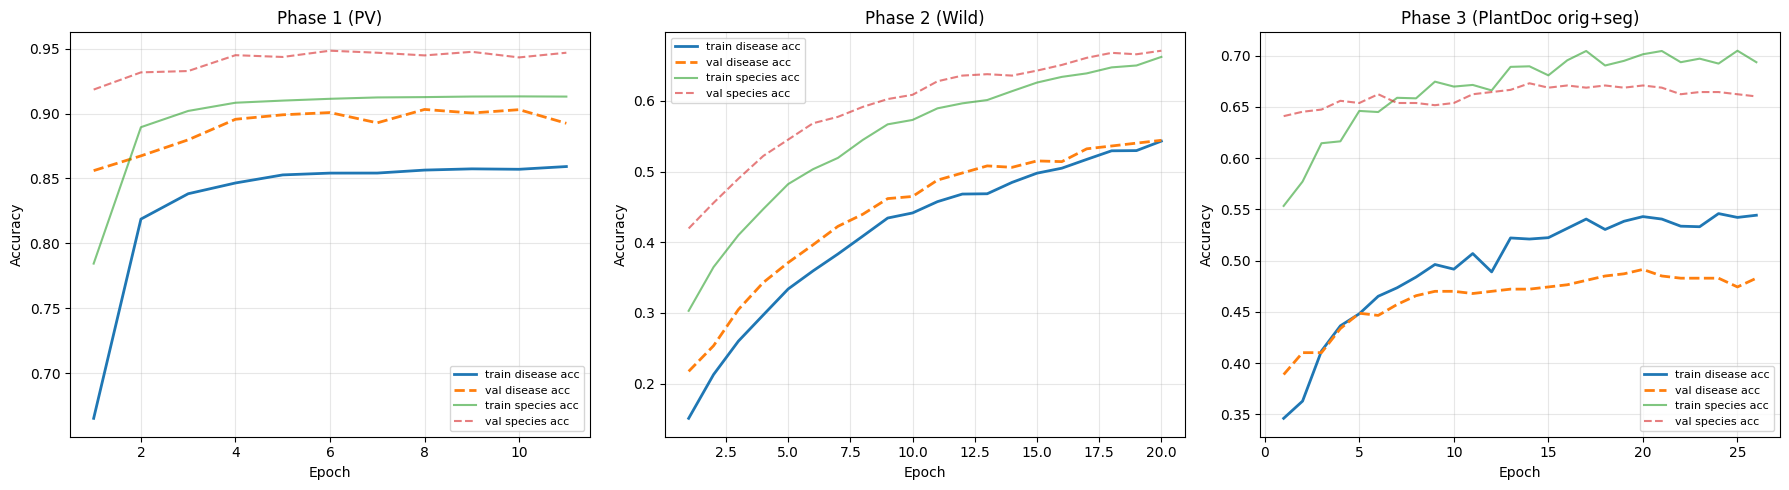

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase_labels = ['Phase 1 (PV)', 'Phase 2 (Wild)', 'Phase 3 (PlantDoc orig+seg)']
histories = [h_p1, h_p2, h_p3]

for ax, h, title in zip(axes, histories, phase_labels):
    epochs = range(1, len(h.history['disease_accuracy']) + 1)
    ax.plot(epochs, h.history['disease_accuracy'],     label='train disease acc', lw=2)
    ax.plot(epochs, h.history['val_disease_accuracy'], label='val disease acc',   lw=2, linestyle='--')
    ax.plot(epochs, h.history['species_accuracy'],     label='train species acc', lw=1.5, alpha=0.6)
    ax.plot(epochs, h.history['val_species_accuracy'], label='val species acc',   lw=1.5, alpha=0.6, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(COMBINED_REPORT_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Évaluation sur PlantDoc test (original)

Tête maladie directe + variante avec masquage espèce. On rapporte **Top-1, Top-3, macro F1**.


In [25]:
def load_plantdoc_arrays(test_dir):
    imgs, glob_labels = [], []
    for pd_cls, pv_cls in valid_pd_mapping.items():
        g = pv_label_to_idx.get(pv_cls)
        cls_dir = test_dir / pd_cls
        if g is None or g not in allowed_set or not cls_dir.exists():
            continue
        for p in sorted(cls_dir.iterdir()):
            if not p.is_file():
                continue
            raw = tf.io.read_file(str(p))
            img = tf.image.decode_image(raw, channels=3, expand_animations=False)
            img.set_shape([None, None, 3])
            img = tf.image.resize(img, IMG_SIZE)
            imgs.append(tf.cast(img, tf.float32).numpy())
            glob_labels.append(g)
    return np.array(imgs), np.array(glob_labels)


def topk_accuracy(probs, y_true_pos, k=3):
    hits = 0
    for i, t in enumerate(y_true_pos):
        if t in np.argsort(probs[i])[-k:][::-1]:
            hits += 1
    return hits / len(y_true_pos)


X_test, y_test_glob = load_plantdoc_arrays(PLANTDOC_TEST_DIR)
y_test_pos     = np.array([global_to_pos[g] for g in y_test_glob])
y_test_species = np.array([int(pv_to_species_arr[g]) for g in y_test_glob])
print(f'PlantDoc test (original) : {len(X_test)} images / {len(set(y_test_glob))} classes')

preds = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
disease_probs = preds['disease']
species_probs = preds['species']
disease_pred  = np.argmax(disease_probs, axis=1)
species_pred  = np.argmax(species_probs, axis=1)

pd_top1 = accuracy_score(y_test_pos, disease_pred)
pd_top3 = topk_accuracy(disease_probs, y_test_pos, k=3)
pd_f1_dis = f1_score(y_test_pos, disease_pred, average='macro', zero_division=0)
pd_f1_sp  = f1_score(y_test_species, species_pred, average='macro', zero_division=0)

print('PlantDoc test (original) - Tete maladie directe')
print(f'  Top-1 : {pd_top1*100:.2f} % | Top-3 : {pd_top3*100:.2f} %')
print(f'  Macro F1 (maladie) : {pd_f1_dis*100:.2f} % | Macro F1 (espece) : {pd_f1_sp*100:.2f} %')

PlantDoc test (original) : 236 images / 27 classes
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step   
PlantDoc test (original) - Tete maladie directe
  Top-1 : 50.42 % | Top-3 : 77.97 %
  Macro F1 (maladie) : 49.13 % | Macro F1 (espece) : 60.77 %


In [26]:
# Variante avec masquage espece (contrainte soft)
species_mask = np.zeros((n_species, n_allowed), dtype=np.float32)
for s in range(n_species):
    for g in species_disease_global[s]:
        species_mask[s, global_to_pos[g]] = 1.0

disease_probs_masked = disease_probs.copy()
for i, sp in enumerate(species_pred):
    disease_probs_masked[i] *= species_mask[sp]
    rs = disease_probs_masked[i].sum()
    if rs > 0:
        disease_probs_masked[i] /= rs

disease_pred_masked = np.argmax(disease_probs_masked, axis=1)
pd_top1_masked = accuracy_score(y_test_pos, disease_pred_masked)
pd_top3_masked = topk_accuracy(disease_probs_masked, y_test_pos, k=3)
pd_f1_masked   = f1_score(y_test_pos, disease_pred_masked, average='macro', zero_division=0)

print('PlantDoc test (original) - Tete maladie + masquage espece')
print(f'  Top-1 : {pd_top1_masked*100:.2f} % | Top-3 : {pd_top3_masked*100:.2f} % | Macro F1 : {pd_f1_masked*100:.2f} %')

PlantDoc test (original) - Tete maladie + masquage espece
  Top-1 : 49.15 % | Top-3 : 66.53 % | Macro F1 : 46.86 %


## 22. Évaluation sur PlantDoc test (segmenté)

On vérifie aussi la performance sur le rendu segmenté (utile si l'app mobile segmente avant envoi).


In [27]:
X_test_seg, y_test_seg_glob = load_plantdoc_arrays(seg_test_dir)
y_test_seg_pos = np.array([global_to_pos[g] for g in y_test_seg_glob])

preds_seg = model.predict(X_test_seg, batch_size=BATCH_SIZE, verbose=1)
seg_disease_pred = np.argmax(preds_seg['disease'], axis=1)

pdseg_top1 = accuracy_score(y_test_seg_pos, seg_disease_pred)
pdseg_top3 = topk_accuracy(preds_seg['disease'], y_test_seg_pos, k=3)
pdseg_f1   = f1_score(y_test_seg_pos, seg_disease_pred, average='macro', zero_division=0)

print(f'PlantDoc test (segmente) : {len(X_test_seg)} images')
print(f'  Top-1 : {pdseg_top1*100:.2f} % | Top-3 : {pdseg_top3*100:.2f} % | Macro F1 : {pdseg_f1*100:.2f} %')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
PlantDoc test (segmente) : 236 images
  Top-1 : 48.31 % | Top-3 : 75.42 % | Macro F1 : 45.63 %


## 23. Évaluation sur PlantVillage test

Mesure la rétention des connaissances studio (robustesse à l'oubli catastrophique).


In [28]:
pv_imgs, y_pv_pos_list, y_pv_sp_list = [], [], []
for img_tensor, lbl_tensor in pv_test_raw.filter(in_allowed):
    g = int(lbl_tensor.numpy())
    img_r = tf.cast(tf.image.resize(img_tensor, IMG_SIZE), tf.float32).numpy()
    pv_imgs.append(img_r)
    y_pv_pos_list.append(int(pv_to_pos_arr[g]))
    y_pv_sp_list.append(int(pv_to_species_arr[g]))

X_pv_test = np.array(pv_imgs)
y_pv_pos  = np.array(y_pv_pos_list)
y_pv_sp   = np.array(y_pv_sp_list)

preds_pv        = model.predict(X_pv_test, batch_size=BATCH_SIZE, verbose=1)
pv_disease_pred = np.argmax(preds_pv['disease'], axis=1)

pv_top1 = accuracy_score(y_pv_pos, pv_disease_pred)
pv_top3 = topk_accuracy(preds_pv['disease'], y_pv_pos, k=3)
pv_f1   = f1_score(y_pv_pos, pv_disease_pred, average='macro', zero_division=0)

print(f'PlantVillage test ({n_allowed} classes, {len(X_pv_test)} images) :')
print(f'  Top-1 : {pv_top1*100:.2f} % | Top-3 : {pv_top3*100:.2f} % | Macro F1 : {pv_f1*100:.2f} %')

184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step
PlantVillage test (27 classes, 5887 images) :
  Top-1 : 80.62 % | Top-3 : 94.89 % | Macro F1 : 74.82 %


## 24. Résumé comparatif (Top-1 / Top-3 / macro F1)

Comparaison du modèle combiné avec les deux meilleures approches précédentes.


In [29]:
# Baselines (mesurees dans les notebooks precedents)
BASE_TWO_HEAD = {  # jalon4_two_head.ipynb
    'pd_top1': 0.4915, 'pd_top3': 0.7458, 'pd_f1': 0.4823,
    'pd_top1_masked': 0.5085, 'pd_f1_masked': 0.5022,
    'pv_top1': 0.8289, 'pv_top3': 0.9596, 'pv_f1': 0.7789,
}
BASE_SEG = {  # jalon4_segmentation_experiment.ipynb (mixte orig+seg, espace 38 classes)
    'pd_top1': 0.5169, 'pd_f1': 0.5017,
    'pv_top1': 0.6291, 'pv_f1': 0.5406,
}

summary_df = pd.DataFrame([
    {'modele': 'Two-head (direct)',
     'PD top1': BASE_TWO_HEAD['pd_top1'], 'PD top3': BASE_TWO_HEAD['pd_top3'], 'PD F1': BASE_TWO_HEAD['pd_f1'],
     'PV top1': BASE_TWO_HEAD['pv_top1'], 'PV top3': BASE_TWO_HEAD['pv_top3'], 'PV F1': BASE_TWO_HEAD['pv_f1']},
    {'modele': 'Two-head (+masquage)',
     'PD top1': BASE_TWO_HEAD['pd_top1_masked'], 'PD top3': np.nan, 'PD F1': BASE_TWO_HEAD['pd_f1_masked'],
     'PV top1': BASE_TWO_HEAD['pv_top1'], 'PV top3': BASE_TWO_HEAD['pv_top3'], 'PV F1': BASE_TWO_HEAD['pv_f1']},
    {'modele': 'Segmentation (mixte 38cls)',
     'PD top1': BASE_SEG['pd_top1'], 'PD top3': np.nan, 'PD F1': BASE_SEG['pd_f1'],
     'PV top1': BASE_SEG['pv_top1'], 'PV top3': np.nan, 'PV F1': BASE_SEG['pv_f1']},
    {'modele': 'COMBINE (direct)',
     'PD top1': pd_top1, 'PD top3': pd_top3, 'PD F1': pd_f1_dis,
     'PV top1': pv_top1, 'PV top3': pv_top3, 'PV F1': pv_f1},
    {'modele': 'COMBINE (+masquage)',
     'PD top1': pd_top1_masked, 'PD top3': pd_top3_masked, 'PD F1': pd_f1_masked,
     'PV top1': pv_top1, 'PV top3': pv_top3, 'PV F1': pv_f1},
])

pct_cols = ['PD top1', 'PD top3', 'PD F1', 'PV top1', 'PV top3', 'PV F1']
summary_fmt = summary_df.copy()
for c in pct_cols:
    summary_fmt[c] = (summary_fmt[c] * 100).round(2)
display(summary_fmt)
summary_fmt.to_csv(COMBINED_REPORT_DIR / 'summary_comparison.csv', index=False)

best_pd = max(pd_top1, pd_top1_masked)
print(f"\nDelta PlantDoc top-1 (combine vs meilleur two-head) : "
      f"{(best_pd - BASE_TWO_HEAD['pd_top1_masked'])*100:+.2f} pts")
print(f"Delta PlantVillage top-1 (combine vs segmentation)  : "
      f"{(pv_top1 - BASE_SEG['pv_top1'])*100:+.2f} pts")

,modele,PD top1,PD top3,PD F1,PV top1,PV top3,PV F1
0,Two-head (direct),49.15,74.58,48.23,82.89,95.96,77.89
1,Two-head (+masquage),50.85,NaN,50.22,82.89,95.96,77.89
2,Segmentation (mixte 38cls),51.69,NaN,50.17,62.91,NaN,54.06
3,COMBINE (direct),50.42,77.97,49.13,80.62,94.89,74.82
4,COMBINE (+masquage),49.15,66.53,46.86,80.62,94.89,74.82



Delta PlantDoc top-1 (combine vs meilleur two-head) : -0.43 pts
Delta PlantVillage top-1 (combine vs segmentation)  : +17.71 pts


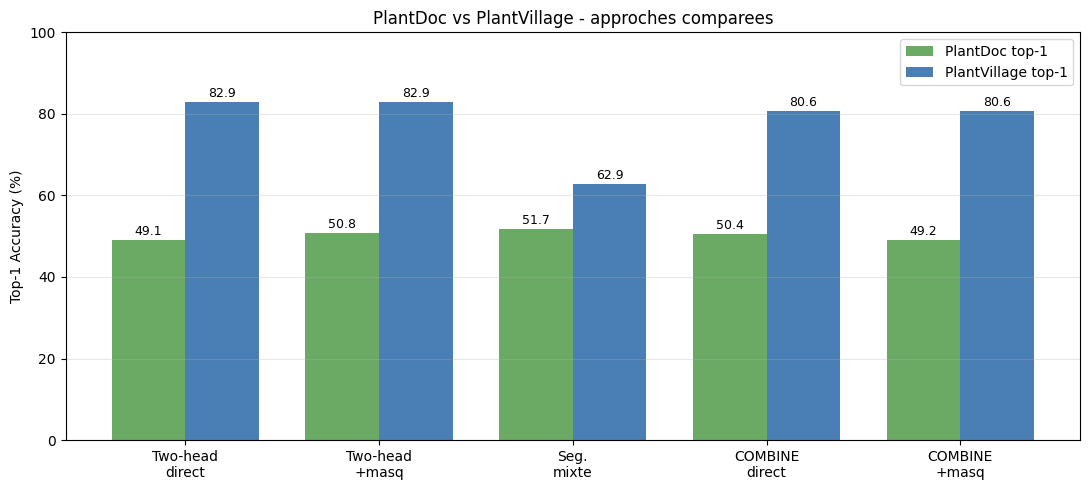

In [30]:
# Graphique comparatif PlantDoc top-1 / top-3 vs PlantVillage top-1
methods = ['Two-head\ndirect', 'Two-head\n+masq', 'Seg.\nmixte', 'COMBINE\ndirect', 'COMBINE\n+masq']
pd_t1 = [BASE_TWO_HEAD['pd_top1'], BASE_TWO_HEAD['pd_top1_masked'], BASE_SEG['pd_top1'], pd_top1, pd_top1_masked]
pv_t1 = [BASE_TWO_HEAD['pv_top1'], BASE_TWO_HEAD['pv_top1'], BASE_SEG['pv_top1'], pv_top1, pv_top1]

x = np.arange(len(methods))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, [v*100 for v in pd_t1], w, label='PlantDoc top-1', color='#6aaa64')
b2 = ax.bar(x + w/2, [v*100 for v in pv_t1], w, label='PlantVillage top-1', color='#4a7fb5')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('PlantDoc vs PlantVillage - approches comparees')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(COMBINED_REPORT_DIR / 'comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 25. Analyse d'erreurs

### 25.1 Rapport de classification (tête maladie, PlantDoc original)


In [31]:
label_names = [pos_to_name[p] for p in range(n_allowed)]
print(classification_report(
    y_test_pos, disease_pred, target_names=label_names, zero_division=0))

                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.80      0.40      0.53        10
                  Apple___Cedar_apple_rust       0.38      0.50      0.43        10
                           Apple___healthy       0.32      0.78      0.45         9
                       Blueberry___healthy       0.25      0.27      0.26        11
                          Cherry___healthy       0.31      0.40      0.35        10
Corn___Cercospora_leaf_spot Gray_leaf_spot       0.25      0.25      0.25         4
                        Corn___Common_rust       0.75      0.90      0.82        10
               Corn___Northern_Leaf_Blight       0.54      0.58      0.56        12
                         Grape___Black_rot       0.50      0.25      0.33         8
                           Grape___healthy       0.89      0.67      0.76        12
                           Peach___healthy       0.50      0.11      0.18  

### 25.2 Matrice de confusion (maladie)

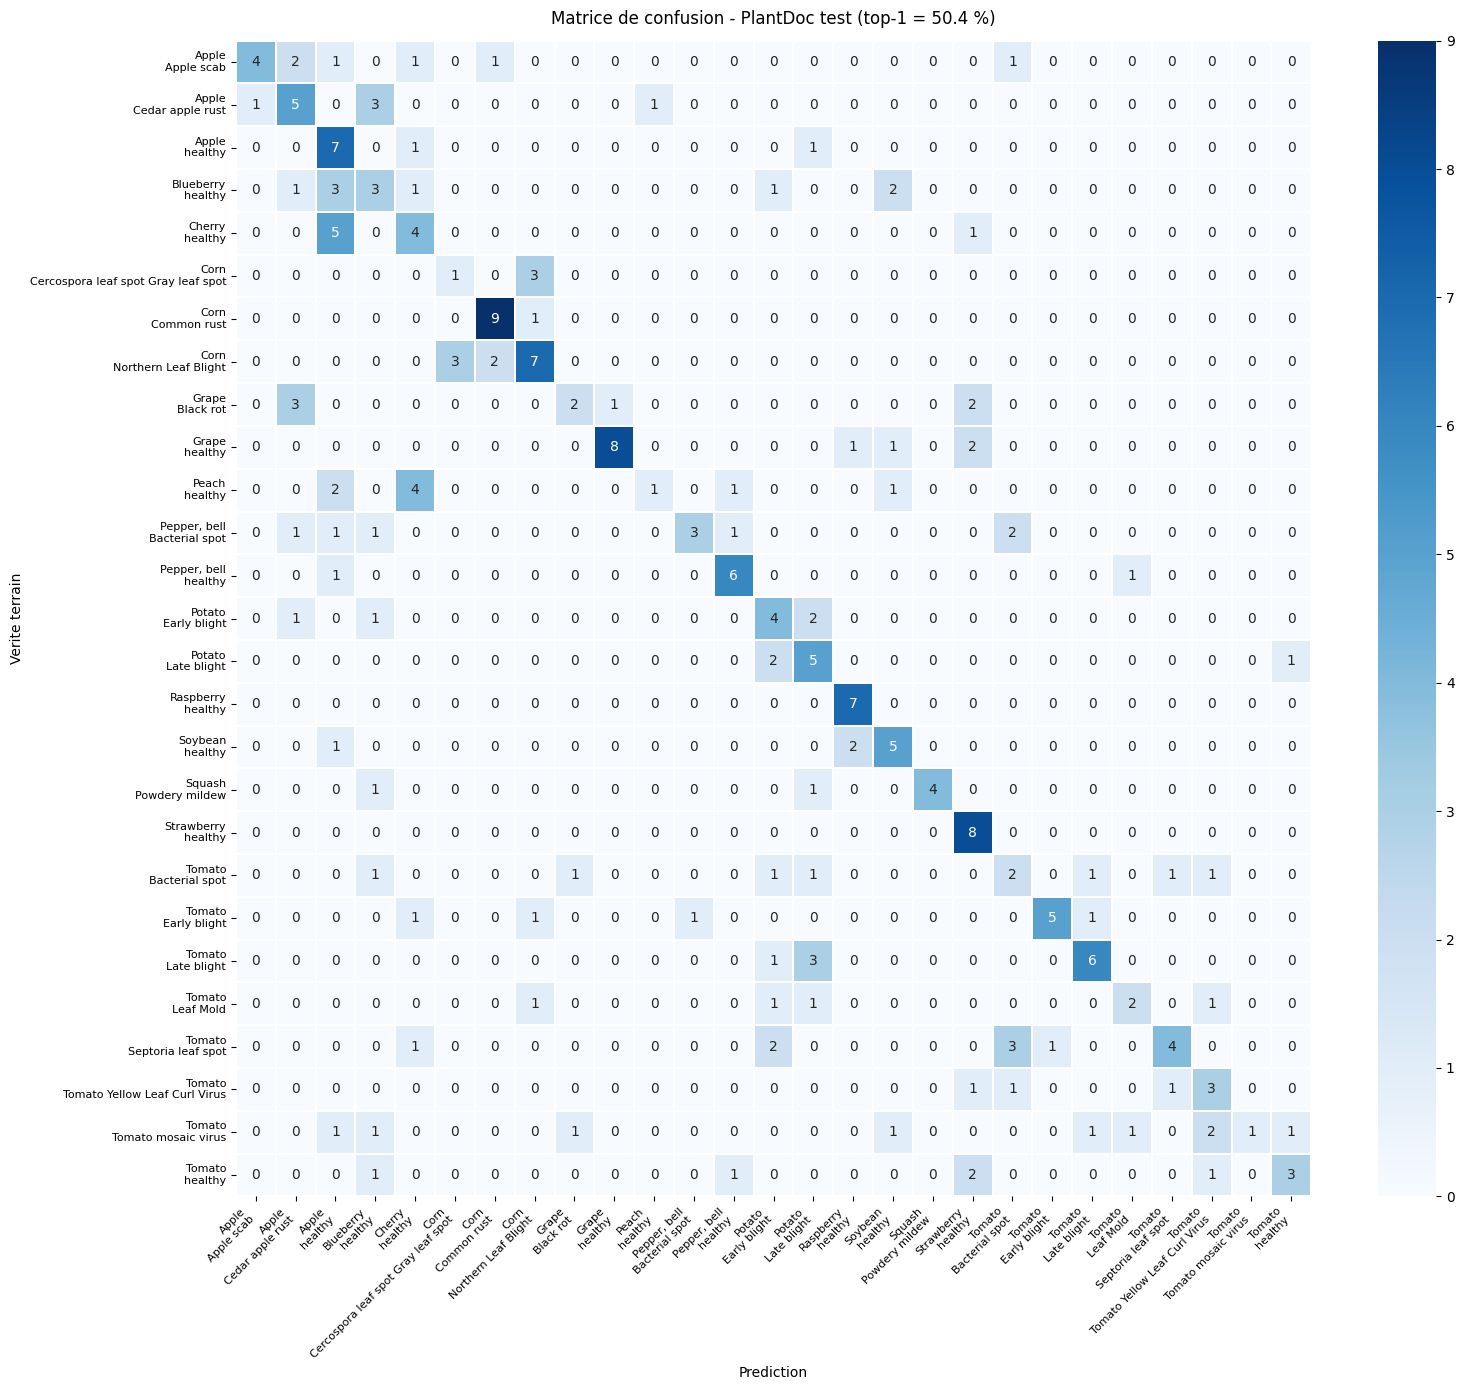

In [32]:
cm = confusion_matrix(y_test_pos, disease_pred, labels=list(range(n_allowed)))
short_names = [n.replace('___', '\n').replace('_', ' ') for n in label_names]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax, linewidths=0.3)
ax.set_title(f'Matrice de confusion - PlantDoc test (top-1 = {pd_top1*100:.1f} %)', pad=12)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite terrain')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(COMBINED_REPORT_DIR / 'confusion_disease.png', dpi=150, bbox_inches='tight')
plt.show()

### 25.3 Décomposition espèce vs maladie

On sépare deux types d'erreurs : (a) le modèle se trompe **de plante**, ou (b) il reconnaît la
plante mais **confond la maladie**. La tête espèce donne une lecture directe de ce diagnostic.


In [33]:
true_species_of_pos = {pos: species_to_idx[species_of(pos_to_name[pos])] for pos in range(n_allowed)}
pred_species_from_disease = np.array([true_species_of_pos[p] for p in disease_pred])
true_species_arr = np.array([true_species_of_pos[p] for p in y_test_pos])

plant_correct   = pred_species_from_disease == true_species_arr
disease_correct = disease_pred == y_test_pos

err_df = pd.DataFrame({
    'true_species': [species_names[s] for s in true_species_arr],
    'plant_correct': plant_correct,
    'disease_correct': disease_correct,
})
plant_summary = (
    err_df.groupby('true_species')
    .agg(n=('plant_correct', 'size'),
         plant_acc=('plant_correct', 'mean'),
         disease_acc=('disease_correct', 'mean'))
    .sort_values('n', ascending=False)
)
plant_summary_fmt = plant_summary.copy()
plant_summary_fmt['plant_acc']   = (plant_summary_fmt['plant_acc'] * 100).round(1)
plant_summary_fmt['disease_acc'] = (plant_summary_fmt['disease_acc'] * 100).round(1)
display(plant_summary_fmt)
plant_summary_fmt.to_csv(COMBINED_REPORT_DIR / 'per_species_summary.csv')

n_total = len(y_test_pos)
n_wrong = int((~disease_correct).sum())
n_wrong_plant = int((~plant_correct).sum())
n_right_plant_wrong_disease = int(((plant_correct) & (~disease_correct)).sum())
print(f'\nErreurs maladie totales : {n_wrong}/{n_total} ({n_wrong/n_total*100:.1f} %)')
print(f'  dont mauvaise plante               : {n_wrong_plant} ({n_wrong_plant/n_total*100:.1f} %)')
print(f'  dont bonne plante, mauvaise maladie: {n_right_plant_wrong_disease} ({n_right_plant_wrong_disease/n_total*100:.1f} %)')

,n,plant_acc,disease_acc
true_species,,,
Tomato,69,62.3,37.7
Apple,29,69.0,55.2
Corn,26,100.0,65.4
Grape,20,55.0,50.0
"Pepper,_bell",17,58.8,52.9
Potato,16,81.2,56.2
Blueberry,11,27.3,27.3
Cherry,10,40.0,40.0
Peach,9,11.1,11.1



Erreurs maladie totales : 117/236 (49.6 %)
  dont mauvaise plante               : 81 (34.3 %)
  dont bonne plante, mauvaise maladie: 36 (15.3 %)


### 25.4 Top erreurs les plus confiantes (original vs segmenté)

Les erreurs à forte confiance sont les plus instructives. On affiche l'image originale et sa
version segmentée pour diagnostiquer si l'erreur vient du fond, du cadrage ou d'une vraie
confusion visuelle.


,true,pred,confidence
41,Corn___Northern_Leaf_Blight,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.876644
116,Grape___Black_rot,Grape___healthy,0.850294
39,Corn___Northern_Leaf_Blight,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.847714
40,Corn___Northern_Leaf_Blight,Corn___Common_rust,0.828930
38,Corn___Northern_Leaf_Blight,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.786454
76,Tomato___healthy,"Pepper,_bell___healthy",0.776374
44,Peach___healthy,Cherry___healthy,0.755570
110,Grape___healthy,Strawberry___healthy,0.727672
17,"Pepper,_bell___Bacterial_spot",Apple___Cedar_apple_rust,0.675649
61,Soybean___healthy,Raspberry___healthy,0.668493


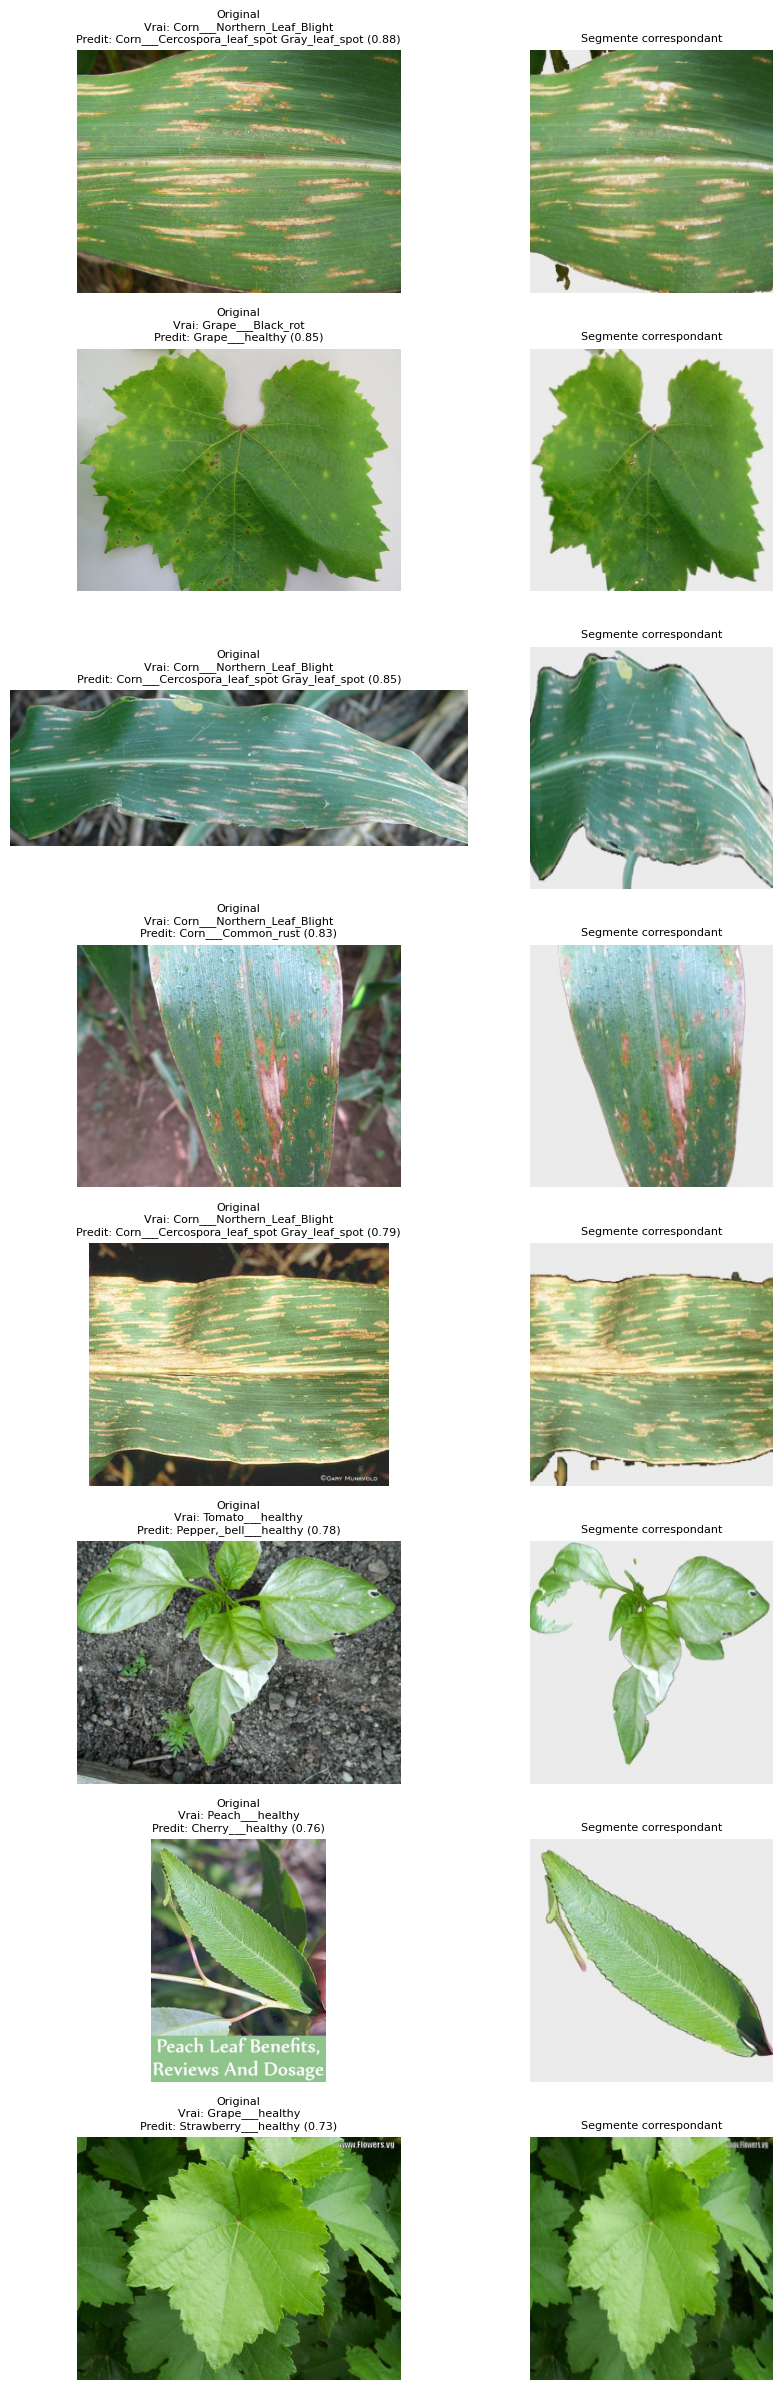

In [34]:
# On reconstruit les chemins du test original dans le meme ordre que load_plantdoc_arrays
orig_test_paths_ordered = []
for pd_cls, pv_cls in valid_pd_mapping.items():
    g = pv_label_to_idx.get(pv_cls)
    cls_dir = PLANTDOC_TEST_DIR / pd_cls
    if g is None or g not in allowed_set or not cls_dir.exists():
        continue
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            orig_test_paths_ordered.append(p)

disease_conf = disease_probs[np.arange(len(disease_pred)), disease_pred]
error_rows = []
for i, p in enumerate(orig_test_paths_ordered):
    if disease_pred[i] == y_test_pos[i]:
        continue
    seg_candidate = seg_test_dir / p.parent.name / p.with_suffix('.jpg').name
    error_rows.append({
        'path': p,
        'seg_path': seg_candidate if seg_candidate.exists() else None,
        'true': pos_to_name[y_test_pos[i]],
        'pred': pos_to_name[disease_pred[i]],
        'confidence': float(disease_conf[i]),
    })

errors_df = pd.DataFrame(error_rows).sort_values('confidence', ascending=False)
display(errors_df[['true', 'pred', 'confidence']].head(20))
errors_df.assign(
    path=errors_df['path'].astype(str),
    seg_path=errors_df['seg_path'].astype(str),
).to_csv(COMBINED_REPORT_DIR / 'top_errors.csv', index=False)

n_show = min(8, len(errors_df))
fig, axes = plt.subplots(n_show, 2, figsize=(9, 3 * n_show))
if n_show == 1:
    axes = np.array([axes])
for row_idx, (_, row) in enumerate(errors_df.head(n_show).iterrows()):
    axes[row_idx, 0].imshow(Image.open(row['path']).convert('RGB'))
    axes[row_idx, 0].set_title(
        f"Original\nVrai: {row['true']}\nPredit: {row['pred']} ({row['confidence']:.2f})", fontsize=8)
    axes[row_idx, 0].axis('off')
    if row['seg_path'] is not None and Path(row['seg_path']).exists():
        axes[row_idx, 1].imshow(Image.open(row['seg_path']).convert('RGB'))
        axes[row_idx, 1].set_title('Segmente correspondant', fontsize=8)
    else:
        axes[row_idx, 1].text(0.5, 0.5, 'Segmente indisponible', ha='center', va='center')
    axes[row_idx, 1].axis('off')
plt.tight_layout()
plt.savefig(COMBINED_REPORT_DIR / 'error_examples.png', dpi=120, bbox_inches='tight')
plt.show()

## 26. Sauvegarde des résultats

In [35]:
results = {
    'model': 'two_head_seg_MobileNetV3Small',
    'phase3_mix': {'pd_original': MIX_RATIO_PD_ORIG, 'pd_segmented': MIX_RATIO_PD_SEG, 'pv_replay': MIX_RATIO_PV},
    'plantdoc_original': {
        'top1_direct': float(pd_top1), 'top3_direct': float(pd_top3),
        'macro_f1_disease': float(pd_f1_dis), 'macro_f1_species': float(pd_f1_sp),
        'top1_masked': float(pd_top1_masked), 'top3_masked': float(pd_top3_masked),
        'macro_f1_masked': float(pd_f1_masked),
    },
    'plantdoc_segmented': {
        'top1': float(pdseg_top1), 'top3': float(pdseg_top3), 'macro_f1': float(pdseg_f1),
    },
    'plantvillage': {
        'top1': float(pv_top1), 'top3': float(pv_top3), 'macro_f1': float(pv_f1),
    },
    'error_breakdown': {
        'n_total': int(n_total), 'n_wrong': int(n_wrong),
        'n_wrong_plant': int(n_wrong_plant),
        'n_right_plant_wrong_disease': int(n_right_plant_wrong_disease),
    },
    'baselines': {
        'two_head': BASE_TWO_HEAD,
        'segmentation_mixed': BASE_SEG,
    },
}

out_path = COMBINED_REPORT_DIR / 'two_head_seg_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Resultats sauvegardes dans {out_path}')

Resultats sauvegardes dans /reports/two_head_seg/two_head_seg_results.json
